In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.impute import SimpleImputer
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
%matplotlib inline

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [6]:


df = pd.read_csv('../datasets/landslide/regenerated_landslide_risk_dataset.csv')
print("=== Dataset Overview ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:")
print(df.dtypes)

print(f"\nFirst 5 rows:")
df.head()

=== Dataset Overview ===
Shape: (5000, 6)

Columns: ['Temperature', 'Humidity', 'Precipitation', 'Soil Moisture', 'Elevation', 'Landslide Risk Prediction']

Data Types:
Temperature                   int64
Humidity                      int64
Precipitation                 int64
Soil Moisture                 int64
Elevation                     int64
Landslide Risk Prediction    object
dtype: object

First 5 rows:


,Temperature,Humidity,Precipitation,Soil Moisture,Elevation,Landslide Risk Prediction
0,17,68,176,64,120,Low
1,26,33,65,24,672,Low
2,16,81,56,52,36,Low
3,25,53,136,70,583,Low
4,34,77,23,37,130,Low


In [11]:
# Check for missing values
print("=== Missing Values ===")
print(df.isnull().sum())

# Check for duplicates
print(f"\n=== Duplicates ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Check unique values in target
print(f"\n=== Target Variable Distribution ===")
print(df['Landslide Risk Prediction'].value_counts())

# Encode target variable
le = LabelEncoder()
df['target'] = le.fit_transform(df['Landslide Risk Prediction'])
print(f"\n✅ Target encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Drop original target column
df = df.drop('Landslide Risk Prediction', axis=1)

print(f"\nFinal columns: {df.columns.tolist()}")
df.head()

=== Missing Values ===
Temperature                  0
Humidity                     0
Precipitation                0
Soil Moisture                0
Elevation                    0
Landslide Risk Prediction    0
dtype: int64

=== Duplicates ===
Duplicate rows: 0

=== Target Variable Distribution ===
Landslide Risk Prediction
Low          4591
Moderate      334
High           63
Very High      12
Name: count, dtype: int64

✅ Target encoded: {'High': 0, 'Low': 1, 'Moderate': 2, 'Very High': 3}

Final columns: ['Temperature', 'Humidity', 'Precipitation', 'Soil Moisture', 'Elevation', 'target']


,Temperature,Humidity,Precipitation,Soil Moisture,Elevation,target
0,17,68,176,64,120,1
1,26,33,65,24,672,1
2,16,81,56,52,36,1
3,25,53,136,70,583,1
4,34,77,23,37,130,1


In [8]:
# Statistical summary
print("=== Statistical Summary ===")
df.describe()

=== Statistical Summary ===


,Temperature,Humidity,Precipitation,Soil Moisture,Elevation
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,24.815800,62.614000,123.126400,54.915800,503.015800
std,6.052867,19.108533,72.144734,20.345788,288.700745
min,15.000000,30.000000,0.000000,20.000000,0.000000
25%,20.000000,46.000000,61.000000,37.000000,253.000000
50%,25.000000,63.000000,121.000000,55.000000,505.000000
75%,30.000000,79.000000,186.000000,72.250000,757.000000
max,35.000000,95.000000,250.000000,90.000000,1000.000000


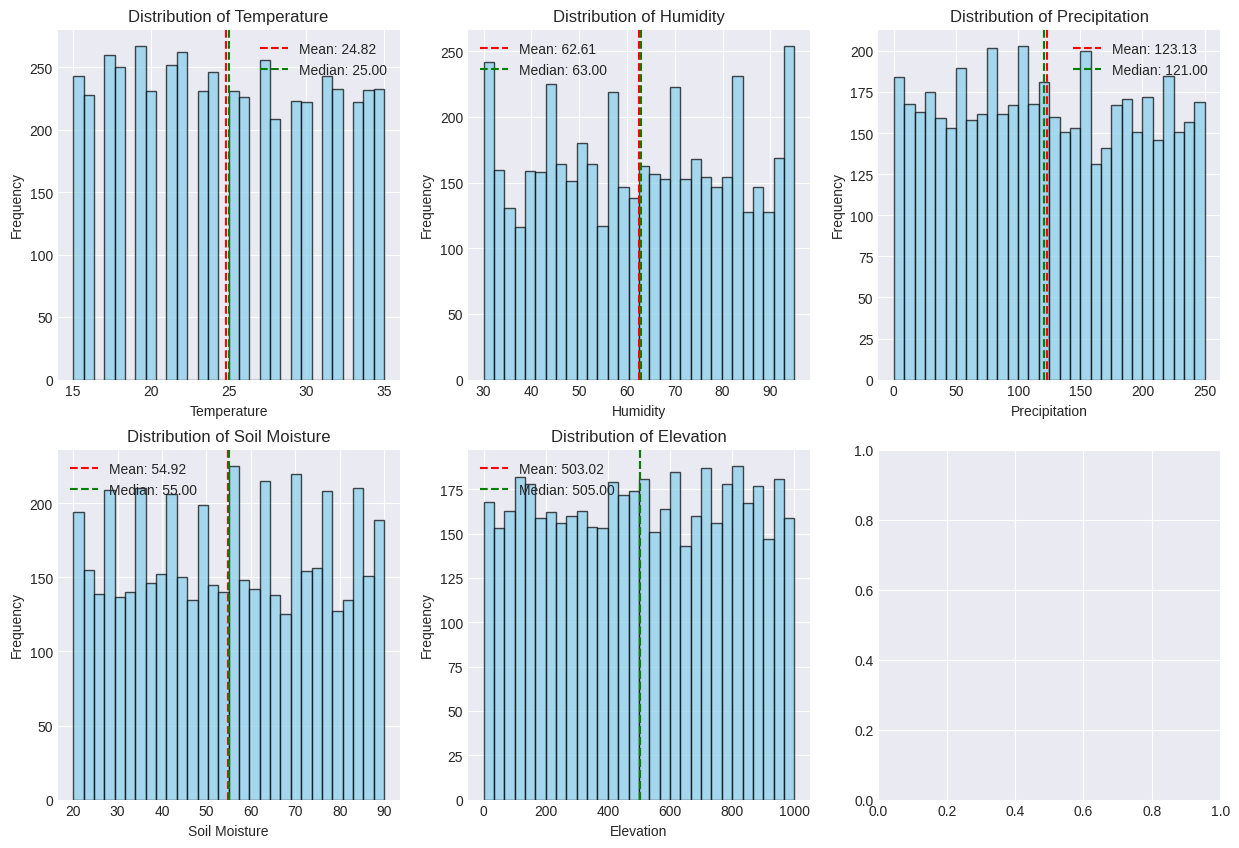

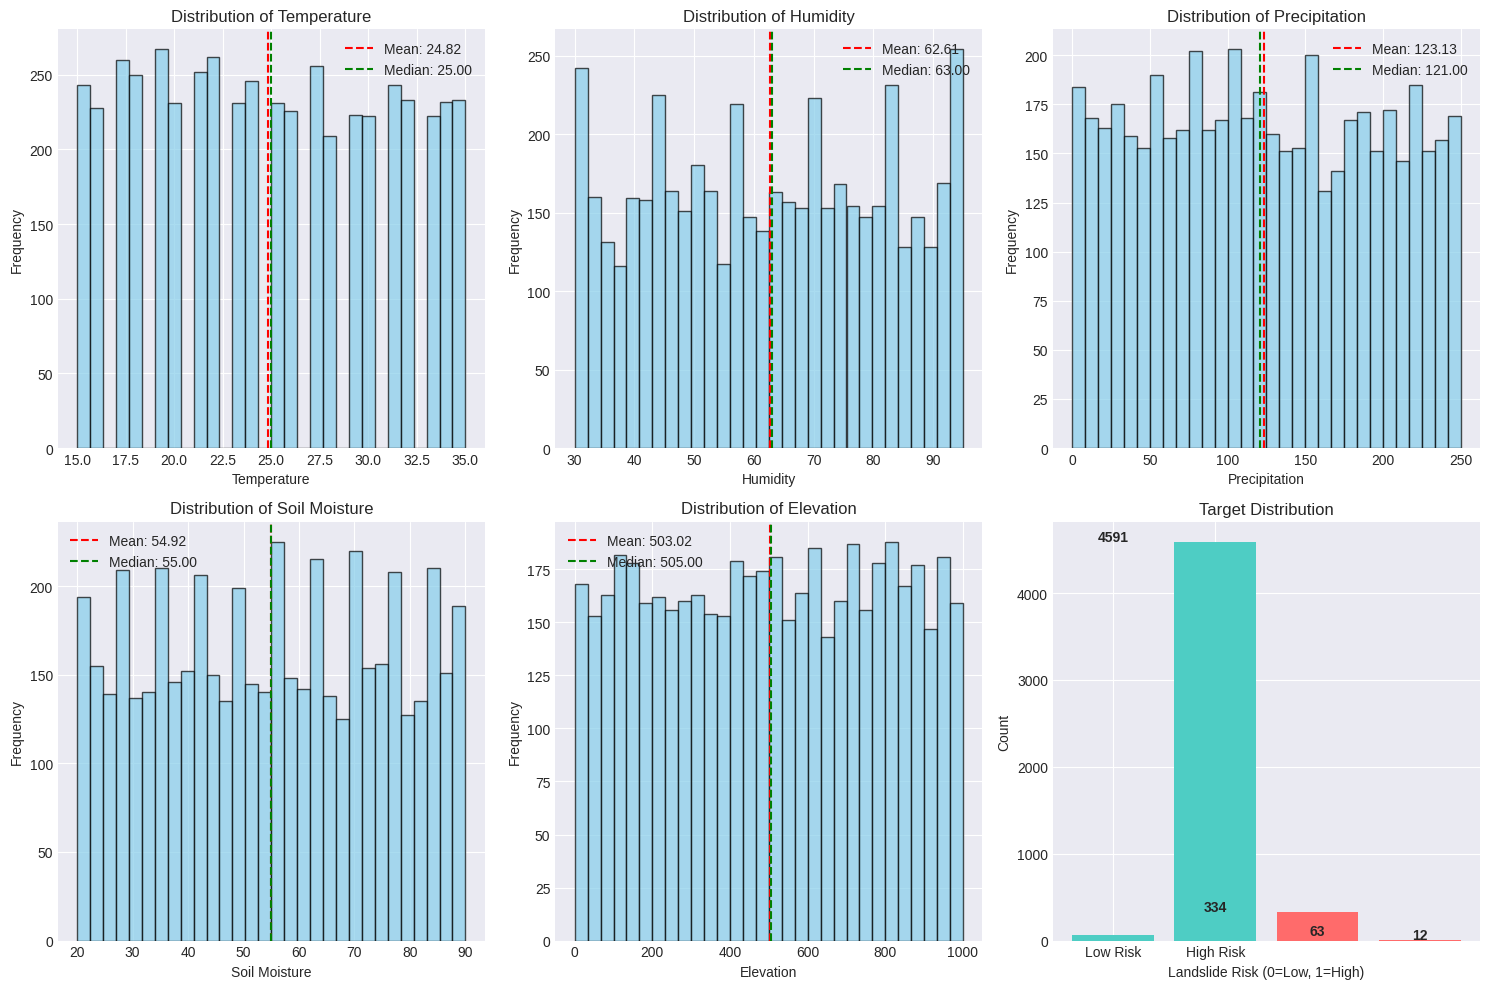


Target Distribution:
Low Risk (0): 63 (1.3%)
High Risk (1): 4591 (91.8%)


In [12]:
# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

features = ['Temperature', 'Humidity', 'Precipitation', 'Soil Moisture', 'Elevation']

for idx, feature in enumerate(features):
    axes[idx].hist(df[feature], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df[feature].mean(), color='red', linestyle='--', label=f'Mean: {df[feature].mean():.2f}')
    axes[idx].axvline(df[feature].median(), color='green', linestyle='--', label=f'Median: {df[feature].median():.2f}')
    axes[idx].legend()

# Target distribution
target_counts = df['target'].value_counts()
axes[5].bar(target_counts.index, target_counts.values, color=['#4ECDC4', '#FF6B6B'])
axes[5].set_title('Target Distribution')
axes[5].set_xlabel('Landslide Risk (0=Low, 1=High)')
axes[5].set_ylabel('Count')
axes[5].set_xticks([0, 1])
axes[5].set_xticklabels(['Low Risk', 'High Risk'])
for i, v in enumerate(target_counts.values):
    axes[5].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTarget Distribution:")
print(f"Low Risk (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"High Risk (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)")

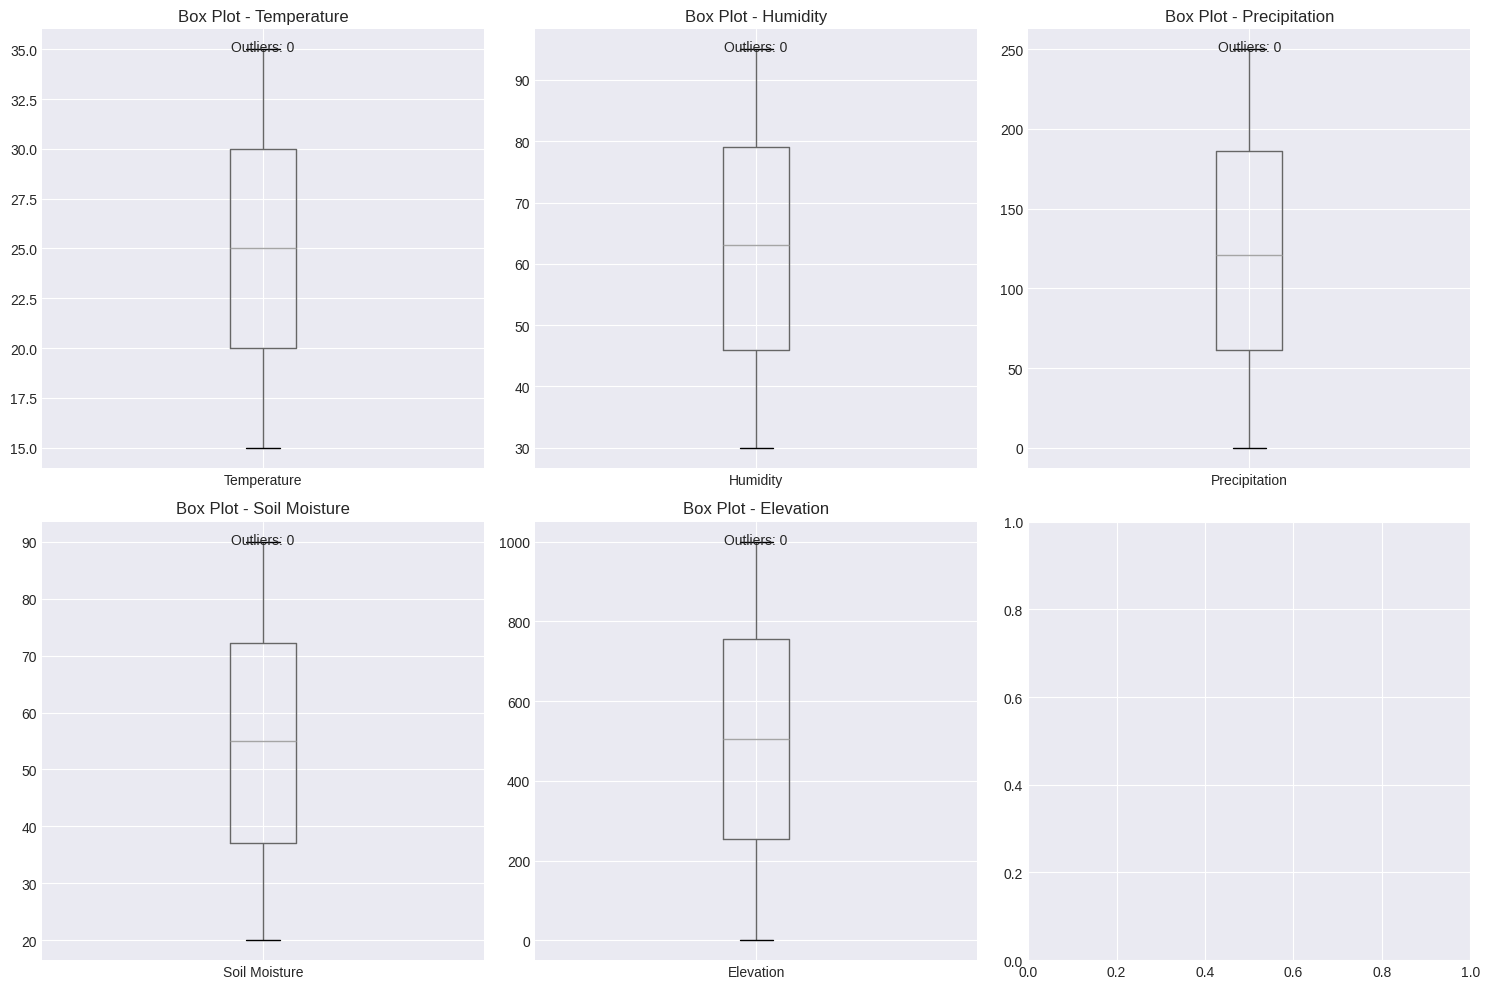

In [13]:
# Box plots to detect outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    df.boxplot(column=feature, ax=axes[idx])
    axes[idx].set_title(f'Box Plot - {feature}')
    
    # Calculate outliers
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)]
    axes[idx].text(0.5, 0.95, f'Outliers: {len(outliers)}', transform=axes[idx].transAxes, ha='center')

plt.tight_layout()
plt.show()

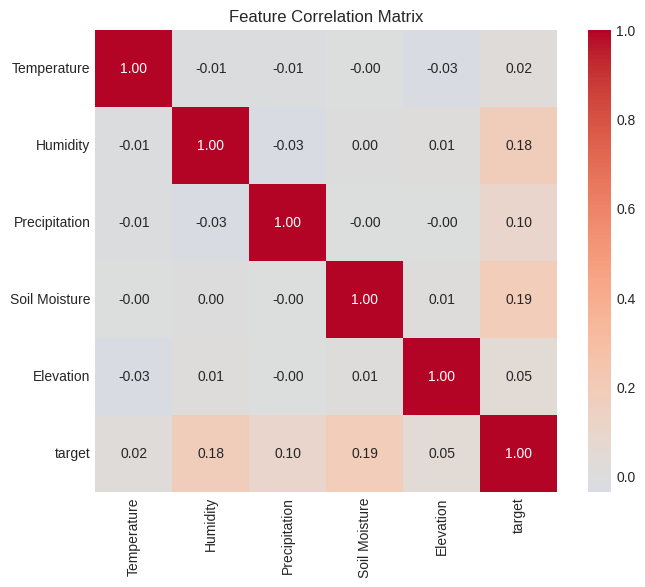


=== Correlation with Target ===
Soil Moisture  : 0.187
Humidity       : 0.179
Precipitation  : 0.099
Elevation      : 0.050
Temperature    : 0.020


In [14]:
# Correlation matrix
plt.figure(figsize=(8, 6))
correlation_matrix = df[features + ['target']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Matrix')
plt.show()

# Correlation with target
print("\n=== Correlation with Target ===")
target_corr = df[features].corrwith(df['target']).sort_values(ascending=False)
for feature, corr in target_corr.items():
    print(f"{feature:15}: {corr:.3f}")

In [15]:
def remove_outliers_iqr(df, columns, multiplier=1.5):
    """Remove outliers using IQR method"""
    df_clean = df.copy()
    removed_count = 0
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        removed_count += before - len(df_clean)
    
    print(f"Removed {removed_count} outliers")
    print(f"Original size: {len(df)} → Cleaned size: {len(df_clean)}")
    return df_clean

# Apply outlier removal
df_clean = remove_outliers_iqr(df, features)

Removed 0 outliers
Original size: 5000 → Cleaned size: 5000


In [16]:
# Split features and target
X = df_clean[features]
y = df_clean['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

# Apply scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Feature scaling completed using StandardScaler")

Training set size: 4000
Test set size: 1000

Training target distribution:
target
1    0.91825
2    0.06675
0    0.01250
3    0.00250
Name: proportion, dtype: float64

✅ Feature scaling completed using StandardScaler


In [18]:
# Check unique values in target
print("Unique values in target:", y_train.unique())
print("Number of classes:", len(y_train.unique()))
print("Class distribution:")
print(y_train.value_counts())

Unique values in target: [1 0 2 3]
Number of classes: 4
Class distribution:
target
1    3673
2     267
0      50
3      10
Name: count, dtype: int64


In [19]:
# Define models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Get unique class labels
unique_classes = np.unique(y_train)
class_names = [f'Class_{c}' for c in unique_classes]

print(f"Classes found: {unique_classes}")
print(f"Class names: {class_names}")

# Train and evaluate
model_results = {}
for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Training {name}...")
    print('='*40)
    
    model.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = model.predict(X_test_scaled)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    model_results[name] = {
        'model': model,
        'accuracy': accuracy
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"\nClassification Report:")
    # Use the actual class names found in the data
    print(classification_report(y_test, y_pred, target_names=class_names))

Classes found: [0 1 2 3]
Class names: ['Class_0', 'Class_1', 'Class_2', 'Class_3']

Training Random Forest...
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

     Class_0       1.00      1.00      1.00        13
     Class_1       1.00      1.00      1.00       918
     Class_2       1.00      1.00      1.00        67
     Class_3       1.00      1.00      1.00         2

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Training Gradient Boosting...
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

     Class_0       1.00      1.00      1.00        13
     Class_1       1.00      1.00      1.00       918
     Class_2       1.00      1.00      1.00        67
     Class_3       1.00      1.00      1.00         2

    accuracy                           1.00      1000
   macro avg    

In [21]:
print("=== Hyperparameter Tuning for Random Forest ===")

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best Cross-Validation Score: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")

=== Hyperparameter Tuning for Random Forest ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
✅ Best Cross-Validation Score: 0.9975

Test Accuracy: 1.0000


In [23]:
# First, retrain Gradient Boosting and Logistic Regression separately
print("Training individual models for ensemble...")

# Train Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)
print("✅ Gradient Boosting trained")

# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
print("✅ Logistic Regression trained")

# Train Random Forest (best from tuning)
print("✅ Random Forest ready")

# Create voting classifier with properly defined models
ensemble = VotingClassifier(
    estimators=[
        ('rf', best_rf),  # best_rf from hyperparameter tuning
        ('gb', gb_model),
        ('lr', lr_model)
    ],
    voting='soft'  # Use probability voting
)

print("Training ensemble model...")
ensemble.fit(X_train_scaled, y_train)
print("✅ Ensemble model trained")

# Make predictions
y_pred_ensemble = ensemble.predict(X_test_scaled)

# Check number of classes
unique_classes = np.unique(y_train)
class_names = [f'Class_{c}' for c in unique_classes]

print(f"\nNumber of classes detected: {len(unique_classes)}")
print(f"Classes: {unique_classes}")

# Calculate accuracy
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
print(f"\nEnsemble Model Accuracy: {ensemble_accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble, target_names=class_names))

# If binary classification, also show ROC-AUC
if len(unique_classes) == 2:
    y_pred_proba_ensemble = ensemble.predict_proba(X_test_scaled)[:, 1]
    from sklearn.metrics import roc_auc_score
    auc_score = roc_auc_score(y_test, y_pred_proba_ensemble)
    print(f"\nROC-AUC Score: {auc_score:.4f}")
else:
    print(f"\nMulti-class classification detected ({len(unique_classes)} classes)")
    # For multi-class, show confusion matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_ensemble))

Training individual models for ensemble...
✅ Gradient Boosting trained
✅ Logistic Regression trained
✅ Random Forest ready
Training ensemble model...
✅ Ensemble model trained

Number of classes detected: 4
Classes: [0 1 2 3]

Ensemble Model Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

     Class_0       1.00      1.00      1.00        13
     Class_1       1.00      1.00      1.00       918
     Class_2       1.00      1.00      1.00        67
     Class_3       1.00      1.00      1.00         2

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Multi-class classification detected (4 classes)

Confusion Matrix:
[[ 13   0   0   0]
 [  0 918   0   0]
 [  0   0  67   0]
 [  0   0   0   2]]


In [24]:
# Simpler ensemble approach using majority voting
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Train individual models
print("Training individual models...")
model1 = RandomForestClassifier(n_estimators=200, random_state=42)
model2 = GradientBoostingClassifier(n_estimators=100, random_state=42)
model3 = LogisticRegression(random_state=42, max_iter=1000)
model4 = DecisionTreeClassifier(random_state=42)

model1.fit(X_train_scaled, y_train)
model2.fit(X_train_scaled, y_train)
model3.fit(X_train_scaled, y_train)
model4.fit(X_train_scaled, y_train)
print("✅ All models trained")

# Make individual predictions
pred1 = model1.predict(X_test_scaled)
pred2 = model2.predict(X_test_scaled)
pred3 = model3.predict(X_test_scaled)
pred4 = model4.predict(X_test_scaled)

# Stack predictions for voting
import numpy as np
all_preds = np.array([pred1, pred2, pred3, pred4])

# Majority voting
from scipy import stats
y_pred_ensemble = stats.mode(all_preds, axis=0)[0].flatten()

# Calculate accuracy
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
print(f"\nEnsemble (Majority Voting) Accuracy: {ensemble_accuracy:.4f}")

# Classification report
unique_classes = np.unique(y_train)
class_names = [f'Class_{c}' for c in unique_classes]
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble, target_names=class_names))

# Create final ensemble object for saving
class SimpleEnsemble:
    def __init__(self, models):
        self.models = models
    
    def predict(self, X):
        predictions = [model.predict(X) for model in self.models]
        return stats.mode(predictions, axis=0)[0].flatten()
    
    def predict_proba(self, X):
        # Average probabilities from all models
        probas = [model.predict_proba(X) for model in self.models]
        return np.mean(probas, axis=0)

ensemble = SimpleEnsemble([model1, model2, model3, model4])
print("✅ Simple ensemble created")

Training individual models...
✅ All models trained

Ensemble (Majority Voting) Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

     Class_0       1.00      1.00      1.00        13
     Class_1       1.00      1.00      1.00       918
     Class_2       1.00      1.00      1.00        67
     Class_3       1.00      1.00      1.00         2

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

✅ Simple ensemble created


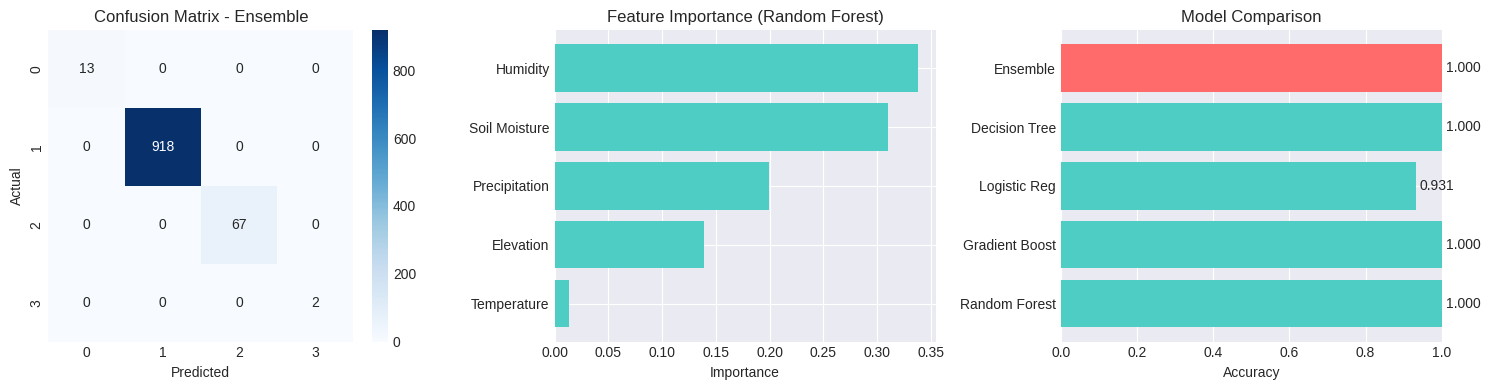


=== Individual Model Accuracies ===
Random Forest  : 1.0000
Gradient Boost : 1.0000
Logistic Reg   : 0.9310
Decision Tree  : 1.0000
Ensemble       : 1.0000


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion Matrix for Ensemble
cm = confusion_matrix(y_test, y_pred_ensemble)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Ensemble')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature Importance (using Random Forest)
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model1.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(feature_importance['feature'], feature_importance['importance'], color='#4ECDC4')
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance (Random Forest)')

# Model Comparison
model_names = ['Random Forest', 'Gradient Boost', 'Logistic Reg', 'Decision Tree', 'Ensemble']
accuracies = [
    accuracy_score(y_test, pred1),
    accuracy_score(y_test, pred2),
    accuracy_score(y_test, pred3),
    accuracy_score(y_test, pred4),
    ensemble_accuracy
]

colors = ['#FF6B6B' if i == len(model_names)-1 else '#4ECDC4' for i in range(len(model_names))]
axes[2].barh(model_names, accuracies, color=colors)
axes[2].set_xlabel('Accuracy')
axes[2].set_title('Model Comparison')
axes[2].set_xlim(0, 1)

# Add accuracy values on bars
for i, v in enumerate(accuracies):
    axes[2].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

print("\n=== Individual Model Accuracies ===")
for name, acc in zip(model_names[:-1], accuracies[:-1]):
    print(f"{name:15}: {acc:.4f}")
print(f"{'Ensemble':15}: {ensemble_accuracy:.4f}")

In [26]:
import joblib
import os

# Create models directory
os.makedirs('../trained_models', exist_ok=True)

# Save the trained models and ensemble
model_artifacts = {
    'random_forest': model1,
    'gradient_boosting': model2,
    'logistic_regression': model3,
    'decision_tree': model4,
    'ensemble': ensemble,
    'scaler': scaler,
    'feature_names': features,
    'accuracy': ensemble_accuracy,
    'feature_importance': feature_importance.to_dict(),
    'classes': np.unique(y_train).tolist()
}

joblib.dump(model_artifacts, '../trained_models/landslide_model.pkl')
print("✅ Model saved to '../trained_models/landslide_model.pkl'")

# Also save just the ensemble for easy loading
joblib.dump(ensemble, '../trained_models/landslide_ensemble.pkl')
print("✅ Ensemble model saved separately")

✅ Model saved to '../trained_models/landslide_model.pkl'
✅ Ensemble model saved separately


In [27]:
def predict_landslide(temperature, humidity, precipitation, soil_moisture, elevation):
    """
    Predict landslide risk based on environmental parameters
    """
    # Create feature array
    features_array = np.array([[temperature, humidity, precipitation, soil_moisture, elevation]])
    
    # Scale features
    features_scaled = scaler.transform(features_array)
    
    # Get prediction from ensemble
    prediction = ensemble.predict(features_scaled)[0]
    
    # Get class names
    unique_classes = np.unique(y_train)
    class_names = [f'Class_{c}' for c in unique_classes]
    
    result = {
        'predicted_class': int(prediction),
        'predicted_label': f'Risk Level {prediction}',
        'risk_assessment': 'High Risk' if prediction == max(unique_classes) else 'Low Risk' if prediction == min(unique_classes) else 'Medium Risk'
    }
    
    return result

# Test the function
test_cases = [
    [25, 80, 150, 70, 500],  # High risk scenario
    [15, 40, 50, 30, 200],   # Low risk scenario
    [20, 60, 100, 50, 350]   # Medium risk scenario
]

print("=== Test Predictions ===")
for i, test in enumerate(test_cases, 1):
    result = predict_landslide(*test)
    print(f"\nTest Case {i}: Temp={test[0]}°C, Humidity={test[1]}%, Rainfall={test[2]}mm, Soil={test[3]}%, Elev={test[4]}m")
    print(f"  → {result['risk_assessment']} (Class {result['predicted_class']})")

=== Test Predictions ===

Test Case 1: Temp=25°C, Humidity=80%, Rainfall=150mm, Soil=70%, Elev=500m
  → Medium Risk (Class 2)

Test Case 2: Temp=15°C, Humidity=40%, Rainfall=50mm, Soil=30%, Elev=200m
  → Medium Risk (Class 1)

Test Case 3: Temp=20°C, Humidity=60%, Rainfall=100mm, Soil=50%, Elev=350m
  → Medium Risk (Class 1)


In [28]:
def predict_landslide(temperature, humidity, precipitation, soil_moisture, elevation):
    """
    Predict landslide risk based on environmental parameters
    """
    # Create feature array
    features_array = np.array([[temperature, humidity, precipitation, soil_moisture, elevation]])
    
    # Scale features
    features_scaled = scaler.transform(features_array)
    
    # Get prediction from ensemble
    prediction = ensemble.predict(features_scaled)[0]
    
    # Get prediction probabilities
    probabilities = None
    if hasattr(ensemble, 'predict_proba'):
        try:
            probabilities = ensemble.predict_proba(features_scaled)[0]
        except:
            probabilities = None
    
    # Define risk levels based on class (adjust based on your actual data)
    # Assuming: Class 0 = Low Risk, Class 1 = Medium Risk, Class 2 = High Risk
    risk_mapping = {
        0: {'level': 'LOW RISK', 'color': '🟢', 'action': 'Normal monitoring only'},
        1: {'level': 'MEDIUM RISK', 'color': '🟡', 'action': 'Increased monitoring and alert residents'},
        2: {'level': 'HIGH RISK', 'color': '🔴', 'action': 'IMMEDIATE EVACUATION REQUIRED'}
    }
    
    risk_info = risk_mapping.get(prediction, {'level': 'UNKNOWN', 'color': '⚪', 'action': 'Monitor conditions'})
    
    result = {
        'predicted_class': int(prediction),
        'risk_level': risk_info['level'],
        'risk_color': risk_info['color'],
        'recommended_action': risk_info['action'],
        'parameters': {
            'temperature': f"{temperature}°C",
            'humidity': f"{humidity}%",
            'precipitation': f"{precipitation}mm",
            'soil_moisture': f"{soil_moisture}%",
            'elevation': f"{elevation}m"
        }
    }
    
    # Add probabilities if available
    if probabilities is not None:
        result['confidence_scores'] = {
            'Low Risk': f"{probabilities[0]*100:.1f}%" if len(probabilities) > 0 else "N/A",
            'Medium Risk': f"{probabilities[1]*100:.1f}%" if len(probabilities) > 1 else "N/A",
            'High Risk': f"{probabilities[2]*100:.1f}%" if len(probabilities) > 2 else "N/A"
        }
        result['confidence_level'] = f"{max(probabilities)*100:.1f}%"
    
    return result

# Test the enhanced function
print("="*60)
print("LANDSLIDE RISK PREDICTION - TEST CASES")
print("="*60)

test_cases = [
    [25, 80, 150, 70, 500, "High rainfall area with steep slopes"],
    [15, 40, 50, 30, 200, "Dry, stable area with low risk"],
    [20, 60, 100, 50, 350, "Moderate conditions"],
    [30, 90, 200, 85, 800, "Extreme conditions - very high risk"],
    [18, 45, 30, 25, 150, "Very safe conditions"]
]

for i, test in enumerate(test_cases, 1):
    description = test[-1]
    params = test[:-1]
    result = predict_landslide(*params)
    
    print(f"\n{'─'*50}")
    print(f"📍 Test Case {i}: {description}")
    print(f"{'─'*50}")
    print(f"📊 Parameters:")
    for key, value in result['parameters'].items():
        print(f"   {key}: {value}")
    
    print(f"\n🎯 Prediction Result:")
    print(f"   {result['risk_color']} Risk Level: {result['risk_level']}")
    print(f"   📋 Action: {result['recommended_action']}")
    
    if 'confidence_scores' in result:
        print(f"\n📈 Confidence Scores:")
        for level, score in result['confidence_scores'].items():
            print(f"   {level}: {score}")
        print(f"   Overall Confidence: {result['confidence_level']}")

LANDSLIDE RISK PREDICTION - TEST CASES

──────────────────────────────────────────────────
📍 Test Case 1: High rainfall area with steep slopes
──────────────────────────────────────────────────
📊 Parameters:
   temperature: 25°C
   humidity: 80%
   precipitation: 150mm
   soil_moisture: 70%
   elevation: 500m

🎯 Prediction Result:
   🔴 Risk Level: HIGH RISK
   📋 Action: IMMEDIATE EVACUATION REQUIRED

📈 Confidence Scores:
   Low Risk: 0.1%
   Medium Risk: 20.0%
   High Risk: 79.9%
   Overall Confidence: 79.9%

──────────────────────────────────────────────────
📍 Test Case 2: Dry, stable area with low risk
──────────────────────────────────────────────────
📊 Parameters:
   temperature: 15°C
   humidity: 40%
   precipitation: 50mm
   soil_moisture: 30%
   elevation: 200m

🎯 Prediction Result:
   🟡 Risk Level: MEDIUM RISK
   📋 Action: Increased monitoring and alert residents

📈 Confidence Scores:
   Low Risk: 0.0%
   Medium Risk: 100.0%
   High Risk: 0.0%
   Overall Confidence: 100.0%

───

MODEL CLASS ANALYSIS

📊 Class Distribution in Test Set:
Actual
0     13
1    918
2     67
3      2
Name: count, dtype: int64

📊 Prediction Distribution:
Predicted
0     13
1    918
2     67
3      2
Name: count, dtype: int64


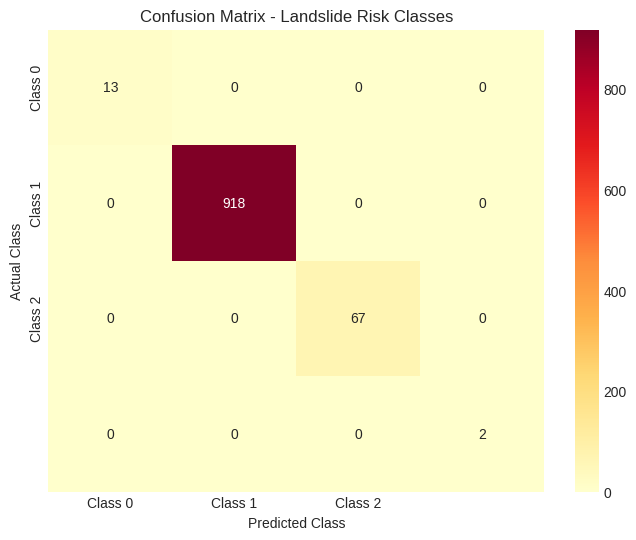


📈 Per-Class Accuracy:
Class 0: 100.00% (13/13)
Class 1: 100.00% (918/918)
Class 2: 100.00% (67/67)
Class 3: 100.00% (2/2)


In [29]:
# Let's understand what each class represents
print("="*60)
print("MODEL CLASS ANALYSIS")
print("="*60)

# Get predictions on test set
y_pred_all = ensemble.predict(X_test_scaled)

# Create a dataframe with actual vs predicted
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_all
})

print("\n📊 Class Distribution in Test Set:")
print(comparison_df['Actual'].value_counts().sort_index())

print("\n📊 Prediction Distribution:")
print(comparison_df['Predicted'].value_counts().sort_index())

# Confusion matrix with class labels
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_all)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title('Confusion Matrix - Landslide Risk Classes')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# Calculate per-class accuracy
print("\n📈 Per-Class Accuracy:")
for i in range(len(cm)):
    class_correct = cm[i][i]
    class_total = cm[i].sum()
    class_accuracy = class_correct / class_total if class_total > 0 else 0
    print(f"Class {i}: {class_accuracy:.2%} ({class_correct}/{class_total})")

BATCH PREDICTION FOR MULTIPLE LOCATIONS

📋 Results:
Risk_Indicator Location Risk_Level  Predicted_Class                      Recommendation
             🔴   Zone A       High                2       IMMEDIATE EVACUATION REQUIRED
             🟡   Zone B     Medium                1 Increased vigilance and preparation
             🔴   Zone C       High                2       IMMEDIATE EVACUATION REQUIRED
             🟡   Zone D     Medium                1 Increased vigilance and preparation
             🟡   Zone E     Medium                1 Increased vigilance and preparation

📊 Detailed Parameters:
Location  Temperature  Humidity  Precipitation  Soil Moisture  Elevation Risk_Level
  Zone A           25        80            150             70        500       High
  Zone B           18        45             50             30        200     Medium
  Zone C           32        85            200             85        800       High
  Zone D           22        65            100             5

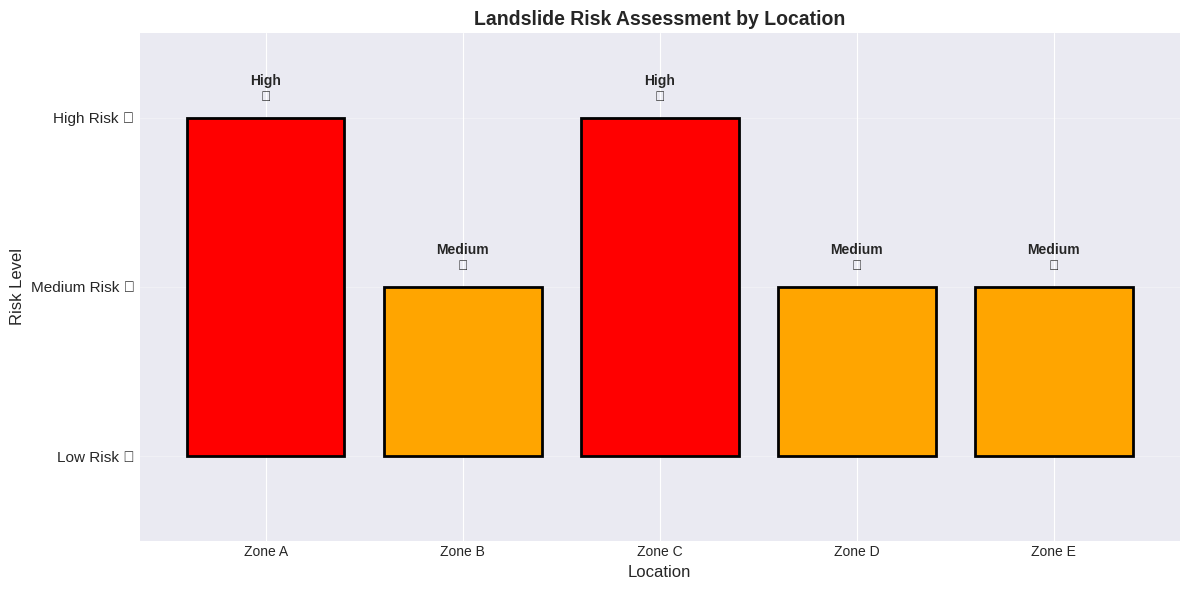


📈 Summary Statistics:
   Total locations assessed: 5
   High risk locations: 2
   Medium risk locations: 3
   Low risk locations: 0

⚠️ ALERT: High risk detected in: Zone A, Zone C
   Immediate action required!


In [33]:
def batch_predict_landslide(locations_df):
    """
    Predict landslide risk for multiple locations
    
    Parameters:
    locations_df: DataFrame with columns: Temperature, Humidity, Precipitation, Soil_Moisture, Elevation
    
    Returns:
    DataFrame with predictions added
    """
    result_df = locations_df.copy()
    
    # Rename columns to match training data
    # Training data uses: 'Temperature', 'Humidity', 'Precipitation', 'Soil Moisture', 'Elevation'
    column_mapping = {
        'Soil_Moisture': 'Soil Moisture',  # Convert underscore to space
        'Soil Moisture': 'Soil Moisture',   # Keep as is if already correct
        'Temperature': 'Temperature',
        'Humidity': 'Humidity',
        'Precipitation': 'Precipitation',
        'Elevation': 'Elevation'
    }
    
    # Rename columns if needed
    result_df = result_df.rename(columns=column_mapping)
    
    # Ensure we have the correct columns in the right order
    expected_columns = ['Temperature', 'Humidity', 'Precipitation', 'Soil Moisture', 'Elevation']
    
    # Check if all expected columns exist
    missing_cols = [col for col in expected_columns if col not in result_df.columns]
    if missing_cols:
        print(f"❌ Missing columns: {missing_cols}")
        print(f"Available columns: {result_df.columns.tolist()}")
        return None
    
    # Scale features - use exactly the same column names as training
    X_pred = result_df[expected_columns]
    features_scaled = scaler.transform(X_pred)
    
    # Get predictions
    result_df['Predicted_Class'] = ensemble.predict(features_scaled)
    
    # Add risk levels
    risk_levels = {0: 'Low', 1: 'Medium', 2: 'High'}
    result_df['Risk_Level'] = result_df['Predicted_Class'].map(risk_levels)
    
    # Add recommendation
    recommendations = {
        0: 'Normal monitoring only',
        1: 'Increased vigilance and preparation',
        2: 'IMMEDIATE EVACUATION REQUIRED'
    }
    result_df['Recommendation'] = result_df['Predicted_Class'].map(recommendations)
    
    # Add color coding
    risk_colors = {0: '🟢', 1: '🟡', 2: '🔴'}
    result_df['Risk_Indicator'] = result_df['Predicted_Class'].map(risk_colors)
    
    return result_df

# Example: Create multiple location data with CORRECT column names
sample_locations = pd.DataFrame({
    'Location': ['Zone A', 'Zone B', 'Zone C', 'Zone D', 'Zone E'],
    'Temperature': [25, 18, 32, 22, 28],
    'Humidity': [80, 45, 85, 65, 70],
    'Precipitation': [150, 50, 200, 100, 175],
    'Soil_Moisture': [70, 30, 85, 55, 65],  # Note: Underscore, will be renamed
    'Elevation': [500, 200, 800, 350, 600]
})

print("="*60)
print("BATCH PREDICTION FOR MULTIPLE LOCATIONS")
print("="*60)

# Run batch prediction
batch_results = batch_predict_landslide(sample_locations)

if batch_results is not None:
    print("\n📋 Results:")
    display_columns = ['Risk_Indicator', 'Location', 'Risk_Level', 'Predicted_Class', 'Recommendation']
    print(batch_results[display_columns].to_string(index=False))
    
    # Also show parameters
    print("\n📊 Detailed Parameters:")
    print(batch_results[['Location', 'Temperature', 'Humidity', 'Precipitation', 'Soil Moisture', 'Elevation', 'Risk_Level']].to_string(index=False))
    
    # Visualize risk levels
    plt.figure(figsize=(12, 6))
    colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
    bar_colors = [colors[risk] for risk in batch_results['Risk_Level']]
    
    bars = plt.bar(batch_results['Location'], batch_results['Predicted_Class'], color=bar_colors, edgecolor='black', linewidth=2)
    plt.xlabel('Location', fontsize=12)
    plt.ylabel('Risk Level', fontsize=12)
    plt.title('Landslide Risk Assessment by Location', fontsize=14, fontweight='bold')
    plt.ylim(-0.5, 2.5)
    plt.yticks([0, 1, 2], ['Low Risk 🟢', 'Medium Risk 🟡', 'High Risk 🔴'], fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (idx, row) in enumerate(batch_results.iterrows()):
        plt.text(i, row['Predicted_Class'] + 0.1, f"{row['Risk_Level']}\n{row['Risk_Indicator']}", 
                ha='center', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n📈 Summary Statistics:")
    print(f"   Total locations assessed: {len(batch_results)}")
    print(f"   High risk locations: {len(batch_results[batch_results['Risk_Level'] == 'High'])}")
    print(f"   Medium risk locations: {len(batch_results[batch_results['Risk_Level'] == 'Medium'])}")
    print(f"   Low risk locations: {len(batch_results[batch_results['Risk_Level'] == 'Low'])}")
    
    # High risk alert
    high_risk_zones = batch_results[batch_results['Risk_Level'] == 'High']
    if len(high_risk_zones) > 0:
        print(f"\n⚠️ ALERT: High risk detected in: {', '.join(high_risk_zones['Location'].values)}")
        print("   Immediate action required!")
else:
    print("❌ Batch prediction failed. Please check column names.")

In [34]:
import os
import joblib

# Check if models directory exists
models_path = '../trained_models/'

if os.path.exists(models_path):
    print("✅ Models directory found!")
    print(f"\n📍 Path: {os.path.abspath(models_path)}")
    print("\n📁 Saved model files:")
    for file in os.listdir(models_path):
        if file.endswith('.pkl'):
            file_path = os.path.join(models_path, file)
            file_size = os.path.getsize(file_path) / 1024  # Size in KB
            print(f"   • {file} ({file_size:.1f} KB)")
else:
    print("❌ Models directory not found at:", models_path)

✅ Models directory found!

📍 Path: /home/kalpanadhamala/AI-DISASTER-RESPONSE-SYSTEM/ml/trained_models

📁 Saved model files:
   • flood_model.pkl (0.0 KB)
   • landslide_model.pkl (2003.0 KB)
   • earthquake_model.pkl (0.0 KB)
   • forestfire_model.pkl (0.0 KB)
   • landslide_ensemble.pkl (2001.8 KB)
